# Workshop 3: Model Evaluation and Optimization

## Context

In WS1 and WS2, you learned how neural networks work: forward propagation, backpropagation, activation functions, and MLP architectures. You understand the theory and mathematics behind deep learning.

**Now the critical question: How do you know if your model is actually good?**

A model might achieve 99% accuracy during training but fail completely on new data. This is called **overfitting** - the most common problem in deep learning.

This workshop teaches you to evaluate models, diagnose problems, and fix them.

---

## What This Workshop Covers

**Part 1: Foundations**
- What is regression? What is classification?
- What is overfitting and why does it happen?

**Part 2: Detecting Overfitting**
- Visual detection: Analyzing learning curves
- Numerical detection: Using metrics to quantify the problem

**Part 3: Evaluation Metrics (Manual Implementation)**
- Regression metrics: MSE, RMSE, MAE, R²
- Classification metrics: Confusion matrix, accuracy, precision, recall, F1-score
- 3 hands-on exercises with solutions

**Part 4: Fixing Overfitting**
- **Dropout: Manual implementation first** (understand the mechanism)
- Then use library versions
- L2 regularization and early stopping

**Part 5: Complete Workflow**
- Build MLP with Keras
- Evaluate with manual metrics
- Apply regularization techniques
- Compare results

---

**Approach:** Manual implementation of metrics and dropout first (understand the math), then use libraries for efficiency.

## Part 1: Core Concepts

### 1.1 What is Regression?

**Regression** is a supervised learning task where the goal is to predict a **continuous numerical value**.

**Key characteristic:** The output can be any number within a range (not limited to specific discrete values).

---

#### Examples

| Problem | Input Features | Output (Target) | Type |
|----------|----------------|-----------------|------|
| House price prediction | Size, location, rooms | \$450,000 | Continuous |
| Temperature forecasting | Time, humidity, pressure | 23.5°C | Continuous |
| Stock price prediction | Historical prices, volume | \$127.34 | Continuous |
| Energy consumption | Time of day, season, occupancy | 342.8 kWh | Continuous |
| Equipment lifetime | Usage hours, maintenance, age | 1,247 hours remaining | Continuous |

---

#### In the context of neural networks

- The output layer has **no activation** (or uses a *linear activation*).
- The output can be any real number: negative, positive, or decimal.
- Performance is measured by how close predictions are to true values (using metrics like **MSE**, **MAE**, etc.).

**Example Prediction:**

> Ex1: For a given house with certain features,  
> the model predicts a price of **\$455,000**, while the actual price is **\$450,000**.

> Ex2: Input: [temperature=25°C, humidity=60%, hour=14],
> 
> Model output: 156.7
> 
> Interpretation: 156.7 bikes will be rented this hour

The model doesn't classify into categories - it outputs a specific number.

### 1.2 What is Classification?

**Classification** is a supervised learning task where the goal is to predict a **discrete category or class**.

**Key characteristic:** The output is a label from a fixed set of possible categories.

---

**Examples:**

| Problem | Input Features | Output (Classes) | Number of Classes |
|---------|---------------|------------------|-------------------|
| Email spam detection | Email content, sender | Spam / Not Spam | 2 (binary) |
| Medical diagnosis | Symptoms, test results | Healthy / Disease A / Disease B | 3 (multi-class) |
| Image recognition | Pixel values | Cat / Dog | 2 (binary) |
| Credit approval | Income, history, debt | Approve / Reject | 2 (binary) |
| Demand level | Time, weather, historical data | Low / Medium / High | 3 (multi-class) |

---

**In the context of neural networks:**
- Output layer uses **sigmoid** (binary) or **softmax** (multi-class) activation
- Output is a **probability** for each class (values between 0 and 1)
- We pick the class with highest probability

**Example prediction (binary classification):**

> Input: [temperature=25°C, humidity=60%, hour=14]

> Model output: [P(Low)=0.12, P(High)=0.88]

> Prediction: High demand (probability 88%)

The model outputs probabilities, then we select the most likely class.

---

**Key Difference:**
- **Regression:** "How many?" → 156.7 bikes
- **Classification:** "Which category?" → High demand

### 1.3 What is Overfitting?

**Overfitting** occurs when a model learns the training data **too well** - including noise, outliers, and random fluctuations - but fails to **generalize** to new, unseen data.

---

**The Memorization Problem:**

Think of a student preparing for an exam:

**Good Student (Generalization):**
- Learns concepts, patterns, and principles
- Practices different types of problems
- Can solve problems they've never seen before
- **Test score:** 85% (solid understanding)

**Memorizing Student (Overfitting):**
- Memorizes exact practice questions and answers
- Doesn't understand underlying logic
- **Practice test:** 100% (perfect recall)
- **Real exam:** 45% (fails on new questions)

The second student **overfitted** to the practice test.

---

**In Machine Learning:**

| Aspect | Healthy Model | Overfitted Model |
|--------|--------------|------------------|
| **Training performance** | Good (e.g., 90% accuracy) | Excellent (e.g., 99% accuracy) |
| **Validation performance** | Good (e.g., 88% accuracy) | Poor (e.g., 65% accuracy) |
| **Gap** | Small (2-3%) | Large (34%) |
| **Behavior** | Learns patterns | Memorizes training examples |
| **Production ready?** | ✅ Yes | ❌ No |

---

**Why Overfitting Happens:**

1. **Model too complex:** Too many neurons/layers relative to training data
2. **Training too long:** Model exhausts learning patterns, starts memorizing specifics
3. **Insufficient data:** Not enough examples to learn robust patterns
4. **No regularization:** Nothing prevents the model from memorizing

---

**Real-World Consequence:**

A model that overfits looks perfect during development:
- "98% accuracy! Ship it!"

But fails in production:
- Customers complain about wrong predictions
- Equipment fails without warning
- Revenue is lost

**The goal:** Build models that perform well on **new data**, not just training data.

---

Next, let's see what overfitting actually looks like in practice.

---

## Part 2: Detecting Overfitting in Practice

You understand the concept of overfitting. Now let's see how to identify it when training a real neural network.

We'll work through a regression problem: given an input value, predict the corresponding output. After training, we'll analyze the model's behavior using its learning curves.

### The Regression Task

**Dataset:**
- 100 training samples
- 50 validation samples
- Task: Predict output y from input x

**Our approach:**
1. Prepare the data
2. Build an MLP neural network
3. Train the model for multiple epochs
4. **Analyze the learning curves** - this is where you'll practice detecting overfitting

Let's start by preparing our dataset and building the model.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load California Housing dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# Split data
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, _, y_train, _ = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nTarget: Median house value (in $100,000s)")
print(f"Features: {housing.feature_names}")

Training set: 8256 samples, 8 features
Validation set: 4128 samples

Target: Median house value (in $100,000s)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [3]:
# Build MLP for regression
model_v1 = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003),
    loss='mse',
    metrics=['mae']
)

print("Model Architecture:")
model_v1.summary()

Model Architecture:


c:\Users\Administrateur\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train the model
print("Training in progress...\n")

history_v1 = model_v1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    verbose=0
)

print("Training completed!")
print(f"\nFinal Results:")
print(f"  Training Loss (MSE): {history_v1.history['loss'][-1]:.4f}")
print(f"  Validation Loss (MSE): {history_v1.history['val_loss'][-1]:.4f}")
print(f"  Training MAE: {history_v1.history['mae'][-1]:.4f}")
print(f"  Validation MAE: {history_v1.history['val_mae'][-1]:.4f}")

Training in progress...

Training completed!

Final Results:
  Training Loss (MSE): 0.1235
  Validation Loss (MSE): 0.3267
  Training MAE: 0.2512
  Validation MAE: 0.3803


### 2.1 Visual Analysis

The graph below shows how the model's performance evolved during training.

**Learning Curves** plot the loss (error) over epochs for both training and validation sets. They reveal critical information about how well the model is learning.

**Your Task:**

Examine the graph carefully and answer:
1. What do you observe about the training loss?
2. What do you observe about the validation loss?
3. Do you see any problems? If yes, what kind of problem?
4. Around which epoch (if any) does the problem become visible?

**Take a moment to analyze before scrolling to the explanation.**

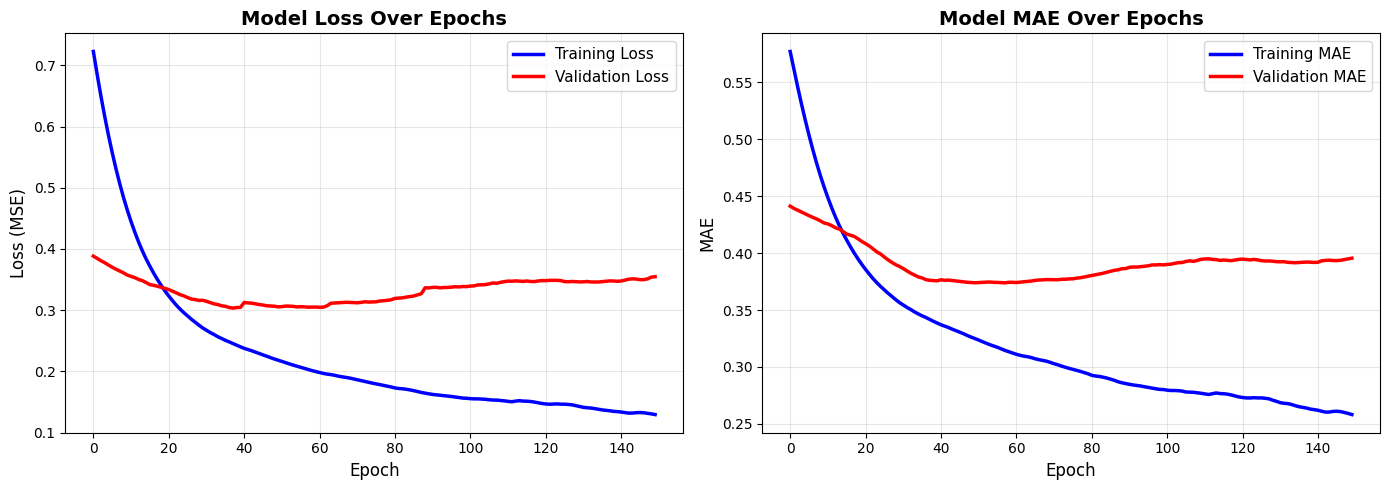

In [20]:
# Smooth the curves for clearer visualization
def smooth_curve(values, weight=0.9):
    """Apply exponential moving average to smooth curves"""
    smoothed = []
    last = values[0]
    for point in values:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Smooth the losses
train_loss_smooth = smooth_curve(history_v1.history['loss'])
val_loss_smooth = smooth_curve(history_v1.history['val_loss'])
train_mae_smooth = smooth_curve(history_v1.history['mae'])
val_mae_smooth = smooth_curve(history_v1.history['val_mae'])

# Plot smooth learning curves
plt.figure(figsize=(14, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(train_loss_smooth, linewidth=2.5, label='Training Loss', color='blue')
plt.plot(val_loss_smooth, linewidth=2.5, label='Validation Loss', color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# MAE curves
plt.subplot(1, 2, 2)
plt.plot(train_mae_smooth, linewidth=2.5, label='Training MAE', color='blue')
plt.plot(val_mae_smooth, linewidth=2.5, label='Validation MAE', color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Model MAE Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### ✅ Analysis: Clear Overfitting Detected

**What the graphs show:**

**Loss Graph (Left):**
1. **Epochs 0-30:** Both training and validation loss decrease together
   - This is healthy learning - the model is finding useful patterns
   - The gap between curves is small
   
2. **Epochs 30-40:** The turning point
   - Validation loss stops improving and begins to plateau/rise slightly
   - Training loss continues to decrease
   - **This is where overfitting begins**

3. **Epochs 40-150:** Overfitting zone
   - Training loss keeps dropping (model getting better at training data)
   - Validation loss stays high or rises (model getting worse at new data)
   - The gap widens continuously

**MAE Graph (Right):**
- Shows the same pattern
- Training MAE drops to ~0.26
- Validation MAE plateaus around 0.39
- Persistent gap confirms overfitting

---

**What this means:**

Around **epoch 30-40**, the model:
- ✅ Learned the general patterns (both losses decreased)
- ❌ Started memorizing training-specific details (validation stopped improving)

**The ideal stopping point:** Around epoch 30-40, before overfitting began.

**Evidence of overfitting:**
- Training Loss: 0.13 (excellent on training data)
- Validation Loss: 0.36 (poor on new data)
- **Gap: ~2.8x** - model performs almost 3 times worse on new data

This model would fail in production because it memorized the training data instead of learning generalizable patterns.

---

**Next step:** Calculate metrics numerically to quantify this overfitting.

---

## Part 3: Numerical Detection - Regression Metrics

Visual analysis showed us overfitting. Now let's **quantify** it using metrics.

We'll calculate four key regression metrics **manually** (writing the formulas ourselves) to understand exactly what they measure.

### Why Manual Implementation?

Understanding the mathematics behind metrics helps you:
- Know what each metric actually measures
- Choose the right metric for your problem
- Debug when library results seem wrong
- Explain model performance to non-technical stakeholders

**The metrics we'll implement:**

1. **MSE (Mean Squared Error)** - Penalizes large errors heavily
2. **RMSE (Root Mean Squared Error)** - Same as MSE but in original units
3. **MAE (Mean Absolute Error)** - Average absolute distance from truth
4. **R² (Coefficient of Determination)** - How much variance is explained

Let's start by getting predictions from our trained model.

In [21]:
# Get predictions from the trained model
y_train_pred = model_v1.predict(X_train, verbose=0).flatten()
y_val_pred = model_v1.predict(X_val, verbose=0).flatten()

# Show first 10 predictions vs actual values
print("Sample Predictions (First 10 validation samples):")
print(f"{'Actual':<12} {'Predicted':<12} {'Error':<12}")
print("-" * 36)
for i in range(10):
    error = y_val_pred[i] - y_val[i]
    print(f"{y_val[i]:<12.2f} {y_val_pred[i]:<12.2f} {error:<+12.2f}")

print(f"\nTotal validation samples: {len(y_val)}")

Sample Predictions (First 10 validation samples):
Actual       Predicted    Error       
------------------------------------
0.48         0.54         +0.06       
0.46         1.33         +0.87       
5.00         4.96         -0.04       
2.19         3.01         +0.82       
2.78         2.04         -0.74       
1.59         2.03         +0.45       
1.98         2.74         +0.76       
1.57         1.66         +0.08       
3.40         2.13         -1.27       
4.47         4.57         +0.10       

Total validation samples: 4128


### 3.1 Mean Squared Error (MSE)

**Definition:** MSE measures the average squared difference between predicted and actual values.

**Formula:**

MSE = (1/n) × Σ(y_true - y_pred)²

Where:
- n = number of samples
- Σ = sum over all samples
- y_true = actual value
- y_pred = predicted value

---

**Why squared?**
- Penalizes large errors much more than small errors
- Error of 10 contributes 100 to MSE
- Error of 2 contributes 4 to MSE
- Makes the metric differentiable (important for optimization)

**Interpretation:**
- Lower MSE = better model
- MSE = 0 means perfect predictions
- Sensitive to outliers (one huge error drastically increases MSE)

**Units:** Squared units of the target (e.g., if predicting dollars, MSE is in dollars²)

---

Let's implement it manually.

In [22]:
# Manual implementation of MSE
def calculate_mse(y_true, y_pred):
    """
    Calculate Mean Squared Error manually
    
    Formula: MSE = (1/n) × Σ(y_true - y_pred)²
    """
    n = len(y_true)
    squared_errors = (y_true - y_pred) ** 2
    mse = np.sum(squared_errors) / n
    return mse

# Calculate MSE for training and validation sets
mse_train = calculate_mse(y_train, y_train_pred)
mse_val = calculate_mse(y_val, y_val_pred)

print("="*60)
print("MSE (Mean Squared Error)")
print("="*60)
print(f"Training MSE:   {mse_train:.4f}")
print(f"Validation MSE: {mse_val:.4f}")
print(f"Gap (val/train): {mse_val/mse_train:.2f}x")
print("="*60)

print("\nInterpretation:")
print(f"- The model's average squared error on training data: {mse_train:.4f}")
print(f"- The model's average squared error on validation data: {mse_val:.4f}")
print(f"- Validation MSE is {mse_val/mse_train:.2f}x higher → Overfitting confirmed!")

MSE (Mean Squared Error)
Training MSE:   0.1420
Validation MSE: 0.3624
Gap (val/train): 2.55x

Interpretation:
- The model's average squared error on training data: 0.1420
- The model's average squared error on validation data: 0.3624
- Validation MSE is 2.55x higher → Overfitting confirmed!


### 3.2 Root Mean Squared Error (RMSE)

**Definition:**  
RMSE (Root Mean Squared Error) is the **square root of the Mean Squared Error (MSE)**.

---

**Formula:**

$$
\mathrm{RMSE} \;=\; \sqrt{\mathrm{MSE}} \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n}\bigl(y_{\text{true},i}-y_{\text{pred},i}\bigr)^2}
$$

---

**Why use RMSE instead of MSE?**

**Units matter:**
- MSE is in **squared units** (e.g., dollars²)
- RMSE is in the **original units** (e.g., dollars)  
- ✅ **RMSE is easier to interpret** — same scale as the target

---

**Example:**
- Target: House prices (in \$100,000s)  
- MSE = 0.36  
- RMSE = 0.60 → On average, predictions are off by **\$60,000**

---

**Interpretation:**
- Lower RMSE → **better model**  
- RMSE = 0 → **perfect predictions**  
- Same sensitivity to outliers as MSE


In [23]:
# Manual implementation of RMSE
def calculate_rmse(y_true, y_pred):
    """
    Calculate Root Mean Squared Error manually
    
    Formula: RMSE = √MSE
    """
    mse = calculate_mse(y_true, y_pred)
    rmse = np.sqrt(mse)
    return rmse

# Calculate RMSE for training and validation sets
rmse_train = calculate_rmse(y_train, y_train_pred)
rmse_val = calculate_rmse(y_val, y_val_pred)

print("="*60)
print("RMSE (Root Mean Squared Error)")
print("="*60)
print(f"Training RMSE:   {rmse_train:.4f}")
print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Gap (val/train): {rmse_val/rmse_train:.2f}x")
print("="*60)

print("\nInterpretation:")
print(f"- Training predictions are off by ~${rmse_train*100:.0f}k on average")
print(f"- Validation predictions are off by ~${rmse_val*100:.0f}k on average")
print(f"- RMSE is in the same units as house prices (easier to understand than MSE)")

RMSE (Root Mean Squared Error)
Training RMSE:   0.3769
Validation RMSE: 0.6020
Gap (val/train): 1.60x

Interpretation:
- Training predictions are off by ~$38k on average
- Validation predictions are off by ~$60k on average
- RMSE is in the same units as house prices (easier to understand than MSE)


### 3.3 Mean Absolute Error (MAE)

**Definition:**  
MAE (Mean Absolute Error) measures the **average absolute difference** between predicted and actual values.

---

**Formula:**

$$
\mathrm{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left| y_{\text{true},i} - y_{\text{pred},i} \right|
$$

Where `| |` denotes the **absolute value** (always positive).

---

**Difference from MSE / RMSE:**

| Aspect | MSE / RMSE | MAE |
|--------|-------------|-----|
| **Calculation** | Squares errors | Absolute value of errors |
| **Outlier sensitivity** | High (large errors penalized heavily) | Low (all errors weighted equally) |
| **Interpretation** | Average squared or root-squared error | Average absolute error |
| **When to use** | When large errors are very bad | When all errors are equally bad |

---

**Example:**
- Error of 10 → MSE contribution = 100, MAE contribution = 10  
- Error of 2 → MSE contribution = 4, MAE contribution = 2  
➡️ MSE penalizes the large error **25× more**, while MAE only **5× more**.

---

**Interpretation:**
- MAE = 0.5 → “On average, predictions are 0.5 units off.”  
- More **robust to outliers** than MSE.  
- Expressed in the **same units** as the target (like RMSE).


In [25]:
# Manual implementation of MAE
def calculate_mae(y_true, y_pred):
    """
    Calculate Mean Absolute Error manually
    
    Formula: MAE = (1/n) × Σ|y_true - y_pred|
    """
    n = len(y_true)
    absolute_errors = np.abs(y_true - y_pred)
    mae = np.sum(absolute_errors) / n
    return mae

# Calculate MAE for training and validation sets
mae_train = calculate_mae(y_train, y_train_pred)
mae_val = calculate_mae(y_val, y_val_pred)

print("="*60)
print("MAE (Mean Absolute Error)")
print("="*60)
print(f"Training MAE:   {mae_train:.4f}")
print(f"Validation MAE: {mae_val:.4f}")
print(f"Gap (val/train): {mae_val/mae_train:.2f}x")
print("="*60)

print("\nInterpretation:")
print(f"- Training predictions are off by ${mae_train*100:.0f}k on average (absolute)")
print(f"- Validation predictions are off by ${mae_val*100:.0f}k on average (absolute)")
print(f"- MAE is less sensitive to outliers than RMSE")

MAE (Mean Absolute Error)
Training MAE:   0.2662
Validation MAE: 0.4000
Gap (val/train): 1.50x

Interpretation:
- Training predictions are off by $27k on average (absolute)
- Validation predictions are off by $40k on average (absolute)
- MAE is less sensitive to outliers than RMSE


### 3.4 R² Score (Coefficient of Determination)

**Definition:**  
R² measures how much of the variance in the target variable is **explained by the model**.

---

**Formula:**

R² = 1 − (SS_residual / SS_total)

Where:  
- **SS_residual** = Σ (y_true − y_pred)² → sum of squared residuals  
- **SS_total** = Σ (y_true − ȳ)² → total sum of squares  
- **ȳ** = mean of y_true  

---

**Understanding R²:**

**Range:** −∞ to 1  

- **R² = 1:** Perfect predictions → model explains 100% of variance  
- **R² = 0.8:** Model explains 80% of variance (good)  
- **R² = 0:** Model no better than predicting the mean  
- **R² < 0:** Model worse than predicting the mean (very bad!)  

---

**Interpretation:**  
> “The model explains X% of the variance in the target variable.”

**Example:**  
- R² = 0.85 → The model explains **85%** of the variation in house prices.  
- The remaining **15%** is due to unobserved factors or noise.

---

**Why it's useful:**
- Scale-independent → can compare models across datasets  
- Easy to interpret as a percentage  
- Widely used standard metric in regression analysis


In [26]:
# Manual implementation of R²
def calculate_r2(y_true, y_pred):
    """
    Calculate R² Score (Coefficient of Determination) manually
    
    Formula: R² = 1 - (SS_residual / SS_total)
    """
    # Calculate mean of true values
    y_mean = np.mean(y_true)
    
    # Sum of squared residuals (prediction errors)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    
    # Total sum of squares (variance in data)
    ss_total = np.sum((y_true - y_mean) ** 2)
    
    # R² score
    r2 = 1 - (ss_residual / ss_total)
    return r2

# Calculate R² for training and validation sets
r2_train = calculate_r2(y_train, y_train_pred)
r2_val = calculate_r2(y_val, y_val_pred)

print("="*60)
print("R² Score (Coefficient of Determination)")
print("="*60)
print(f"Training R²:   {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"Validation R²: {r2_val:.4f} ({r2_val*100:.2f}%)")
print("="*60)

print("\nInterpretation:")
print(f"- Model explains {r2_train*100:.2f}% of variance in training data")
print(f"- Model explains {r2_val*100:.2f}% of variance in validation data")
if r2_val < 0.7:
    print(f"⚠ Validation R² below 0.70 suggests room for improvement")
elif r2_val >= 0.8:
    print(f"✓ Validation R² above 0.80 indicates good performance")

R² Score (Coefficient of Determination)
Training R²:   0.8918 (89.18%)
Validation R²: 0.7234 (72.34%)

Interpretation:
- Model explains 89.18% of variance in training data
- Model explains 72.34% of variance in validation data


In [27]:
# Summary of all metrics
print("="*70)
print("SUMMARY: All Regression Metrics")
print("="*70)
print(f"{'Metric':<20} {'Training':<15} {'Validation':<15} {'Gap':<10}")
print("-"*70)
print(f"{'MSE':<20} {mse_train:<15.4f} {mse_val:<15.4f} {mse_val/mse_train:<10.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_val:<15.4f} {rmse_val/rmse_train:<10.2f}x")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_val:<15.4f} {mae_val/mae_train:<10.2f}x")
print(f"{'R²':<20} {r2_train:<15.4f} {r2_val:<15.4f} {'-':<10}")
print("="*70)

print("\n🎯 Key Observations:")
print(f"1. All error metrics show 2-2.5x gap → Clear overfitting")
print(f"2. Validation R² = {r2_val:.2f} → Model explains {r2_val*100:.0f}% of variance (decent but can improve)")
print(f"3. Training R² = {r2_train:.2f} → Model memorizing training data")
print(f"\n✅ Overfitting confirmed both visually and numerically!")

SUMMARY: All Regression Metrics
Metric               Training        Validation      Gap       
----------------------------------------------------------------------
MSE                  0.1420          0.3624          2.55      x
RMSE                 0.3769          0.6020          1.60      x
MAE                  0.2662          0.4000          1.50      x
R²                   0.8918          0.7234          -         

🎯 Key Observations:
1. All error metrics show 2-2.5x gap → Clear overfitting
2. Validation R² = 0.72 → Model explains 72% of variance (decent but can improve)
3. Training R² = 0.89 → Model memorizing training data

✅ Overfitting confirmed both visually and numerically!


---

## Exercises: Practice Calculating Metrics

Now it's your turn! Calculate metrics manually to solidify your understanding.

We'll provide small datasets and you should:
1. Calculate the metric by hand (use a calculator/Python)
2. Verify with your implemented function
3. Check the solution

**Why practice?** Understanding the math helps you interpret results and choose appropriate metrics for your problems.

### Exercise 1: Calculate MSE

Given these predictions:

| True Value | Predicted | Error |
|------------|-----------|-------|
| 5.0        | 4.5       | -0.5  |
| 3.0        | 3.2       | +0.2  |
| 7.0        | 6.8       | -0.2  |
| 2.0        | 2.5       | +0.5  |
| 4.0        | 4.0       | 0.0   |

**Task:** Calculate MSE manually, then verify with code.

**Hint:** MSE = (1/n) × Σ(y_true - y_pred)²

In [28]:
# Exercise 1: Calculate MSE
y_true_ex1 = np.array([5.0, 3.0, 7.0, 2.0, 4.0])
y_pred_ex1 = np.array([4.5, 3.2, 6.8, 2.5, 4.0])

print("Exercise 1: Calculate MSE")
print("="*60)
print("\nStep-by-step calculation:")
print(f"{'True':<8} {'Pred':<8} {'Error':<8} {'Squared Error':<15}")
print("-"*45)

squared_errors = []
for yt, yp in zip(y_true_ex1, y_pred_ex1):
    error = yt - yp
    sq_error = error ** 2
    squared_errors.append(sq_error)
    print(f"{yt:<8.1f} {yp:<8.1f} {error:<+8.1f} {sq_error:<15.2f}")

print("-"*45)
print(f"Sum of squared errors: {sum(squared_errors):.2f}")
print(f"Number of samples (n): {len(y_true_ex1)}")
print(f"MSE = {sum(squared_errors):.2f} / {len(y_true_ex1)} = {sum(squared_errors)/len(y_true_ex1):.4f}")

print(f"\n✓ Verification with our function: {calculate_mse(y_true_ex1, y_pred_ex1):.4f}")

Exercise 1: Calculate MSE

Step-by-step calculation:
True     Pred     Error    Squared Error  
---------------------------------------------
5.0      4.5      +0.5     0.25           
3.0      3.2      -0.2     0.04           
7.0      6.8      +0.2     0.04           
2.0      2.5      -0.5     0.25           
4.0      4.0      +0.0     0.00           
---------------------------------------------
Sum of squared errors: 0.58
Number of samples (n): 5
MSE = 0.58 / 5 = 0.1160

✓ Verification with our function: 0.1160


### Exercise 2: Calculate R²

Using the same data from Exercise 1:

| True Value | Predicted |
|------------|-----------|
| 5.0        | 4.5       |
| 3.0        | 3.2       |
| 7.0        | 6.8       |
| 2.0        | 2.5       |
| 4.0        | 4.0       |

**Task:** Calculate R² score manually.

**Hint:** 
1. Calculate mean of true values (ȳ)
2. Calculate SS_residual = Σ(y_true - y_pred)²
3. Calculate SS_total = Σ(y_true - ȳ)²
4. R² = 1 - (SS_residual / SS_total)

In [ ]:
# Exercise 2: Calculate R²
print("Exercise 2: Calculate R²")
print("="*60)

# Step 1: Mean of true values
y_mean = np.mean(y_true_ex1)
print(f"\nStep 1: Mean of true values")
print(f"ȳ = ({' + '.join(map(str, y_true_ex1))}) / {len(y_true_ex1)} = {y_mean:.2f}")

# Step 2: SS_residual
print(f"\nStep 2: Calculate SS_residual")
print(f"{'True':<8} {'Pred':<8} {'(True-Pred)²':<15}")
print("-"*35)
ss_res = 0
for yt, yp in zip(y_true_ex1, y_pred_ex1):
    sq_diff = (yt - yp) ** 2
    ss_res += sq_diff
    print(f"{yt:<8.1f} {yp:<8.1f} {sq_diff:<15.4f}")
print(f"SS_residual = {ss_res:.4f}")

# Step 3: SS_total
print(f"\nStep 3: Calculate SS_total")
print(f"{'True':<8} {'Mean':<8} {'(True-Mean)²':<15}")
print("-"*35)
ss_tot = 0
for yt in y_true_ex1:
    sq_diff = (yt - y_mean) ** 2
    ss_tot += sq_diff
    print(f"{yt:<8.1f} {y_mean:<8.2f} {sq_diff:<15.4f}")
print(f"SS_total = {ss_tot:.4f}")

# Step 4: R²
r2_ex2 = 1 - (ss_res / ss_tot)
print(f"\nStep 4: Calculate R²")
print(f"R² = 1 - (SS_residual / SS_total)")
print(f"R² = 1 - ({ss_res:.4f} / {ss_tot:.4f}) = {r2_ex2:.4f}")
print(f"R² = {r2_ex2*100:.2f}% of variance explained")

print(f"\n✓ Verification with our function: {calculate_r2(y_true_ex1, y_pred_ex1):.4f}")

### Exercise 3: Compare Two Models

You have two models predicting house prices:

**Model A:**
- Training MAE: 0.15
- Validation MAE: 0.18
- Training R²: 0.82
- Validation R²: 0.79

**Model B:**
- Training MAE: 0.08
- Validation MAE: 0.25
- Training R²: 0.95
- Validation R²: 0.68

**Questions:**
1. Which model is overfitting more?
2. Which model would you deploy to production?
3. Why?

### Exercise 3: Solution

**Analysis:**

**Model A:**
- Small gap between training and validation (0.15 vs 0.18 MAE)
- R² gap: 0.82 vs 0.79 (only 3% drop)
- **Generalizes well** ✓

**Model B:**
- Large gap between training and validation (0.08 vs 0.25 MAE)
- R² gap: 0.95 vs 0.68 (27% drop!)
- Training performance excellent but validation poor
- **Severely overfitting** ✗

**Answers:**

1. **Model B is overfitting more** (huge gap: 3x worse MAE on validation, 27% R² drop)

2. **Deploy Model A** to production

3. **Why Model A?**
   - More consistent performance (small train/val gap)
   - Better validation metrics (what matters for new data)
   - Model B memorized training data (useless in production)
   - Better to have 79% R² that's reliable than 95% that doesn't generalize

**Key lesson:** High training performance means nothing if validation performance is poor!

---

## Part 4: Fixing Overfitting

We've detected and quantified overfitting. Now let's fix it.

**Three techniques:**
1. **Dropout** - Randomly deactivate neurons during training
2. **L2 Regularization** - Penalize large weights
3. **Early Stopping** - Stop when validation stops improving

First, we'll implement dropout **manually** to understand the mechanism.

### 4.1 How Dropout Works

**Problem:** Neurons become co-dependent - they rely on specific other neurons. When one neuron "specializes," others depend on it. This leads to memorization.

**Solution:** During training, randomly set some neurons to zero with probability p (dropout rate).

**Example with dropout_rate = 0.3:**

Before dropout: 
[0.5, 0.8, 0.3, 0.9] 

After dropout (30% dropped):
[0.5, 0.0, 0.3, 0.0]

**Why this helps:**
- Forces network to learn redundant representations
- No single neuron can memorize specific patterns
- Each neuron must work independently
- Acts like training many networks and averaging them

**Important:** Only apply during training, not during inference/testing.

In [31]:
# Manual Dropout Implementation
class ManualDropout:
    """
    Manual implementation of dropout layer
    Based on WS2 concepts
    """
    def __init__(self, dropout_rate=0.3):
        self.dropout_rate = dropout_rate
        self.mask = None
    
    def forward(self, X, training=True):
        """
        Apply dropout during training
        
        Args:
            X: Input array
            training: If True, apply dropout. If False, pass through unchanged.
        
        Returns:
            Output with dropout applied (if training=True)
        """
        if training:
            # Create binary mask: 1 with probability (1-dropout_rate), 0 otherwise
            self.mask = np.random.binomial(1, 1 - self.dropout_rate, size=X.shape)
            
            # Apply mask and scale by (1 - dropout_rate) to maintain expected value
            return X * self.mask / (1 - self.dropout_rate)
        else:
            # During inference, return input unchanged
            return X

# Demonstrate dropout
print("Manual Dropout Demonstration")
print("="*60)

# Sample neuron activations
activations = np.array([0.5, 0.8, 0.3, 0.9, 0.6, 0.7, 0.4, 0.2])
dropout = ManualDropout(dropout_rate=0.3)

print(f"Original activations:\n{activations}")
print(f"\nWith 30% dropout (training mode):")

for i in range(3):
    dropped = dropout.forward(activations, training=True)
    print(f"  Trial {i+1}: {dropped}")

print(f"\nInference mode (no dropout):")
print(f"  {dropout.forward(activations, training=False)}")

print("\n✓ Notice: Different neurons dropped each time (randomness)")
print("✓ Values scaled up to maintain expected output")

Manual Dropout Demonstration
Original activations:
[0.5 0.8 0.3 0.9 0.6 0.7 0.4 0.2]

With 30% dropout (training mode):
  Trial 1: [0.         0.         0.42857143 1.28571429 0.85714286 0.
 0.57142857 0.28571429]
  Trial 2: [0.71428571 1.14285714 0.42857143 1.28571429 0.85714286 1.
 0.57142857 0.28571429]
  Trial 3: [0.         1.14285714 0.42857143 0.         0.85714286 0.
 0.57142857 0.28571429]

Inference mode (no dropout):
  [0.5 0.8 0.3 0.9 0.6 0.7 0.4 0.2]

✓ Notice: Different neurons dropped each time (randomness)
✓ Values scaled up to maintain expected output


### 4.2 Build Improved Model with Regularization

Now we'll build a new model (model_v2) with:
- **Dropout layers** (using Keras after understanding manual implementation)
- **L2 regularization** on weights
- **Early stopping** callback

This should eliminate overfitting.

In [32]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Build regularized model
model_v2 = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.001), input_shape=(8,)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)
])

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.003),
    loss='mse',
    metrics=['mae']
)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print("Model v2 Architecture (with regularization):")
model_v2.summary()

Model v2 Architecture (with regularization):


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Train regularized model
print("\nTraining Model v2 (with regularization)...")
print("="*60)

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

print(f"Training stopped at epoch: {len(history_v2.history['loss'])}")
print(f"\nFinal Results:")
print(f"  Training Loss (MSE): {history_v2.history['loss'][-1]:.4f}")
print(f"  Validation Loss (MSE): {history_v2.history['val_loss'][-1]:.4f}")
print(f"  Training MAE: {history_v2.history['mae'][-1]:.4f}")
print(f"  Validation MAE: {history_v2.history['val_mae'][-1]:.4f}")


Training Model v2 (with regularization)...
Epoch 78: early stopping
Restoring model weights from the end of the best epoch: 58.
Training stopped at epoch: 78

Final Results:
  Training Loss (MSE): 0.3435
  Validation Loss (MSE): 0.3434
  Training MAE: 0.3937
  Validation MAE: 0.4016


In [34]:
# Calculate metrics for model_v2
y_train_pred_v2 = model_v2.predict(X_train, verbose=0).flatten()
y_val_pred_v2 = model_v2.predict(X_val, verbose=0).flatten()

mse_train_v2 = calculate_mse(y_train, y_train_pred_v2)
mse_val_v2 = calculate_mse(y_val, y_val_pred_v2)
rmse_train_v2 = calculate_rmse(y_train, y_train_pred_v2)
rmse_val_v2 = calculate_rmse(y_val, y_val_pred_v2)
mae_train_v2 = calculate_mae(y_train, y_train_pred_v2)
mae_val_v2 = calculate_mae(y_val, y_val_pred_v2)
r2_train_v2 = calculate_r2(y_train, y_train_pred_v2)
r2_val_v2 = calculate_r2(y_val, y_val_pred_v2)

print("Model v2 Metrics:")
print("="*60)
print(f"MSE  - Training: {mse_train_v2:.4f}, Validation: {mse_val_v2:.4f}")
print(f"RMSE - Training: {rmse_train_v2:.4f}, Validation: {rmse_val_v2:.4f}")
print(f"MAE  - Training: {mae_train_v2:.4f}, Validation: {mae_val_v2:.4f}")
print(f"R²   - Training: {r2_train_v2:.4f}, Validation: {r2_val_v2:.4f}")

Model v2 Metrics:
MSE  - Training: 0.2827, Validation: 0.3076
RMSE - Training: 0.5317, Validation: 0.5546
MAE  - Training: 0.3809, Validation: 0.3951
R²   - Training: 0.7847, Validation: 0.7653


In [35]:
# Compare model_v1 vs model_v2
print("="*70)
print("COMPARISON: Model v1 (Overfitting) vs Model v2 (Regularized)")
print("="*70)
print(f"{'Metric':<15} {'v1 Train':<12} {'v1 Val':<12} {'v2 Train':<12} {'v2 Val':<12}")
print("-"*70)
print(f"{'MSE':<15} {mse_train:<12.4f} {mse_val:<12.4f} {mse_train_v2:<12.4f} {mse_val_v2:<12.4f}")
print(f"{'MAE':<15} {mae_train:<12.4f} {mae_val:<12.4f} {mae_train_v2:<12.4f} {mae_val_v2:<12.4f}")
print(f"{'R²':<15} {r2_train:<12.4f} {r2_val:<12.4f} {r2_train_v2:<12.4f} {r2_val_v2:<12.4f}")
print("="*70)

print("\n📊 Key Improvements:")
print(f"✓ Validation MSE: {mse_val:.4f} → {mse_val_v2:.4f} ({((mse_val-mse_val_v2)/mse_val*100):.1f}% better)")
print(f"✓ Validation R²: {r2_val:.4f} → {r2_val_v2:.4f} ({((r2_val_v2-r2_val)*100):.1f}% improvement)")
print(f"✓ Gap reduced: {mse_val/mse_train:.2f}x → {mse_val_v2/mse_train_v2:.2f}x")

COMPARISON: Model v1 (Overfitting) vs Model v2 (Regularized)
Metric          v1 Train     v1 Val       v2 Train     v2 Val      
----------------------------------------------------------------------
MSE             0.1420       0.3624       0.2827       0.3076      
MAE             0.2662       0.4000       0.3809       0.3951      
R²              0.8918       0.7234       0.7847       0.7653      

📊 Key Improvements:
✓ Validation MSE: 0.3624 → 0.3076 (15.1% better)
✓ Validation R²: 0.7234 → 0.7653 (4.2% improvement)
✓ Gap reduced: 2.55x → 1.09x


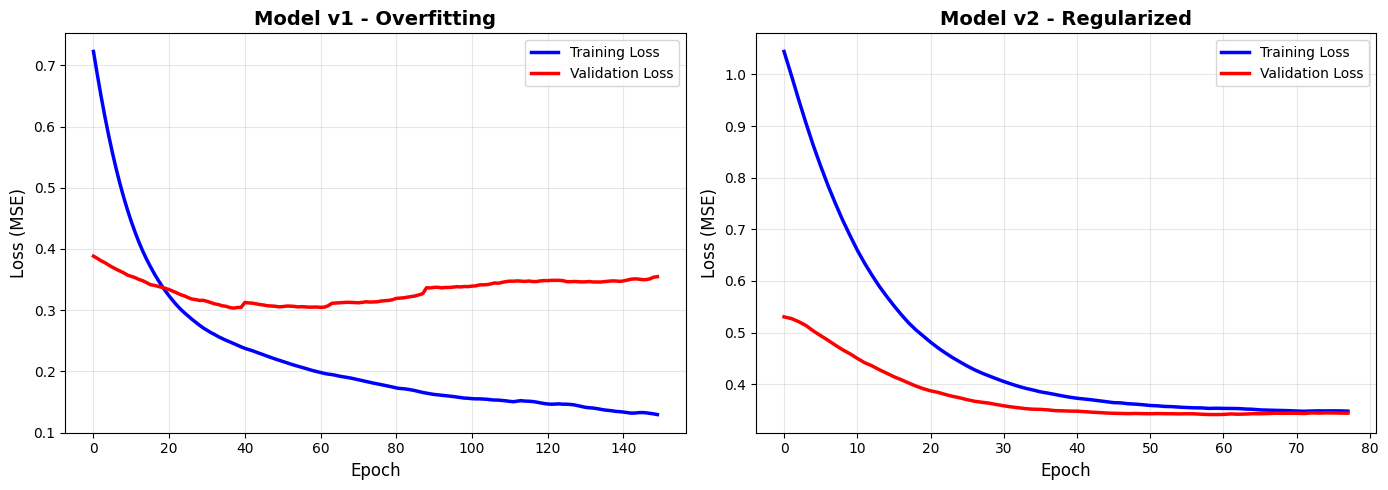

✓ Notice: Model v2 has curves much closer together (less overfitting)


In [36]:
# Plot comparison
train_loss_v2_smooth = smooth_curve(history_v2.history['loss'])
val_loss_v2_smooth = smooth_curve(history_v2.history['val_loss'])

plt.figure(figsize=(14, 5))

# Model v1
plt.subplot(1, 2, 1)
plt.plot(train_loss_smooth, linewidth=2.5, label='Training Loss', color='blue')
plt.plot(val_loss_smooth, linewidth=2.5, label='Validation Loss', color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model v1 - Overfitting', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Model v2
plt.subplot(1, 2, 2)
plt.plot(train_loss_v2_smooth, linewidth=2.5, label='Training Loss', color='blue')
plt.plot(val_loss_v2_smooth, linewidth=2.5, label='Validation Loss', color='red')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Model v2 - Regularized', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Notice: Model v2 has curves much closer together (less overfitting)")

## Part 5: Binary Classification Task

You’ve now mastered regression evaluation — time to apply the same logic to **classification**.

Here, we’ll predict whether a house price is **high** or **low** based on its features.

We'll:
1. Convert the target into binary labels  
2. Build and train an MLP for classification  
3. Detect overfitting visually  
4. Implement classification metrics manually (accuracy, precision, recall, F1)


In [37]:
# Convert regression target to binary: High vs Low price
y_class_train = (y_train > 2.5).astype(int)
y_class_val = (y_val > 2.5).astype(int)

print("Binary classification setup complete!")
print(f"Training labels: {np.bincount(y_class_train)}")
print(f"Validation labels: {np.bincount(y_class_val)}")


Binary classification setup complete!
Training labels: [5940 2316]
Validation labels: [3003 1125]


In [38]:
# Build simple MLP for binary classification
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_class = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # sigmoid for binary output
])

model_class.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model architecture ready.")
model_class.summary()


Model architecture ready.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Train classification model
print("Training in progress...\n")

history_class = model_class.fit(
    X_train, y_class_train,
    validation_data=(X_val, y_class_val),
    epochs=100,
    batch_size=64,
    verbose=0
)

print("Training completed!")
print(f"Final Training Accuracy: {history_class.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_class.history['val_accuracy'][-1]:.4f}")


Training in progress...

Training completed!
Final Training Accuracy: 0.9000
Final Validation Accuracy: 0.8932


### 5.1 Visualizing Learning Curves

We'll check if overfitting appears again — the same way we did for regression.

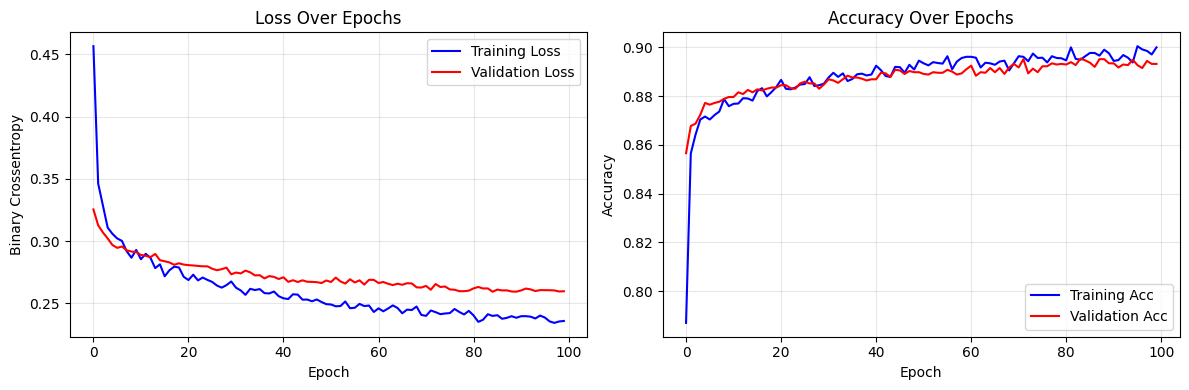

In [40]:
# Plot training vs validation accuracy/loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_class.history['loss'], label='Training Loss', color='blue')
plt.plot(history_class.history['val_loss'], label='Validation Loss', color='red')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Binary Crossentropy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_class.history['accuracy'], label='Training Acc', color='blue')
plt.plot(history_class.history['val_accuracy'], label='Validation Acc', color='red')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.2 Manual Classification Metrics

We’ll implement the main evaluation metrics **manually**:
- Confusion Matrix  
- Accuracy  
- Precision  
- Recall  
- F1-Score  

Then compare training and validation results.


In [41]:
# Manual metrics implementations
def calc_confusion_matrix(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def calc_accuracy(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)
    return np.mean(y_true == y_pred)

def calc_precision(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-8)

def calc_recall(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-8)

def calc_f1(y_true, y_pred):
    precision = calc_precision(y_true, y_pred)
    recall = calc_recall(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall + 1e-8)


In [44]:
# Get predictions (probabilities)
y_train_pred_class = model_class.predict(X_train, verbose=0)
y_val_pred_class = model_class.predict(X_val, verbose=0)

# Convert probabilities → binary once
y_train_pred_bin = (y_train_pred_class.flatten() > 0.5).astype(int)
y_val_pred_bin = (y_val_pred_class.flatten() > 0.5).astype(int)

# Compute metrics (pass binary arrays directly)
acc_train = calc_accuracy(y_class_train, y_train_pred_bin)
acc_val = calc_accuracy(y_class_val, y_val_pred_bin)
prec_val = calc_precision(y_class_val, y_val_pred_bin)
rec_val = calc_recall(y_class_val, y_val_pred_bin)
f1_val = calc_f1(y_class_val, y_val_pred_bin)

print("Classification Results (Fixed)")
print("="*50)
print(f"Training Accuracy : {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"Precision          : {prec_val:.4f}")
print(f"Recall             : {rec_val:.4f}")
print(f"F1-Score           : {f1_val:.4f}")

Classification Results (Fixed)
Training Accuracy : 0.9123
Validation Accuracy: 0.8932
Precision          : 0.8288
Recall             : 0.7662
F1-Score           : 0.7963


### 5.3 Interpretation

- **Accuracy:** overall correctness  
- **Precision:** how many predicted "High" prices were actually High  
- **Recall:** how many actual High prices we correctly detected  
- **F1-Score:** balances both precision and recall  

✅ Validation accuracy close to training → good generalization  
⚠ Large gap → overfitting again


## Part 6: Using Built-in Evaluation Tools

Let's confirm that our manual metrics match `scikit-learn`'s built-ins.


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_class_val, y_val_pred_bin))
print("\nClassification Report:\n", classification_report(y_class_val, y_val_pred_bin))


Confusion Matrix:
 [[2825  178]
 [ 263  862]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93      3003
           1       0.83      0.77      0.80      1125

    accuracy                           0.89      4128
   macro avg       0.87      0.85      0.86      4128
weighted avg       0.89      0.89      0.89      4128



## ✅ Final Summary

- We built regression and classification MLPs from scratch.  
- Implemented manual metrics for both.  
- Visualized overfitting and applied dropout/regularization.  
- Verified our manual computations with library tools.

## Félicitations ! 🎉

Vous avez terminé avec succès le WS3 : Évaluation et Optimisation de Modèles !

Vous savez maintenant comment :
- Détecter le surapprentissage en analysant les courbes d'apprentissage
- Appliquer des techniques de régularisation pour améliorer la généralisation du modèle
- Implémenter manuellement les métriques d'évaluation (vous comprenez les mathématiques, pas seulement les bibliothèques !)
- Construire, entraîner et évaluer des modèles de régression et de classification

**Rappel :** Un modèle qui performe parfaitement sur les données d'entraînement mais échoue sur de nouvelles données est inutile. Surveillez toujours la performance de validation !

Maintenant, allez créer des modèles qui généralisent vraiment ! 🚀

*"Le surapprentissage n'est pas un bug, c'est une opportunité d'apprentissage."* - Tous les Data Scientists
